Loaded source frame resolution: 1536x1536
Executing inference and alignment for architecture: Depth Anything V2 L...


preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.43k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.34GB            

model.safetensors: downloading bytes:           |  0.00B            

...

config.json:   0%|          | 0.00/1.43k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.34GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/503 [00:00<?, ?it/s]

Executing inference and alignment for architecture: Intel DPT DINOv2 L...
Skipping architecture Intel DPT DINOv2 L due to execution fault: Intel/dpt-dinov2-large is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`


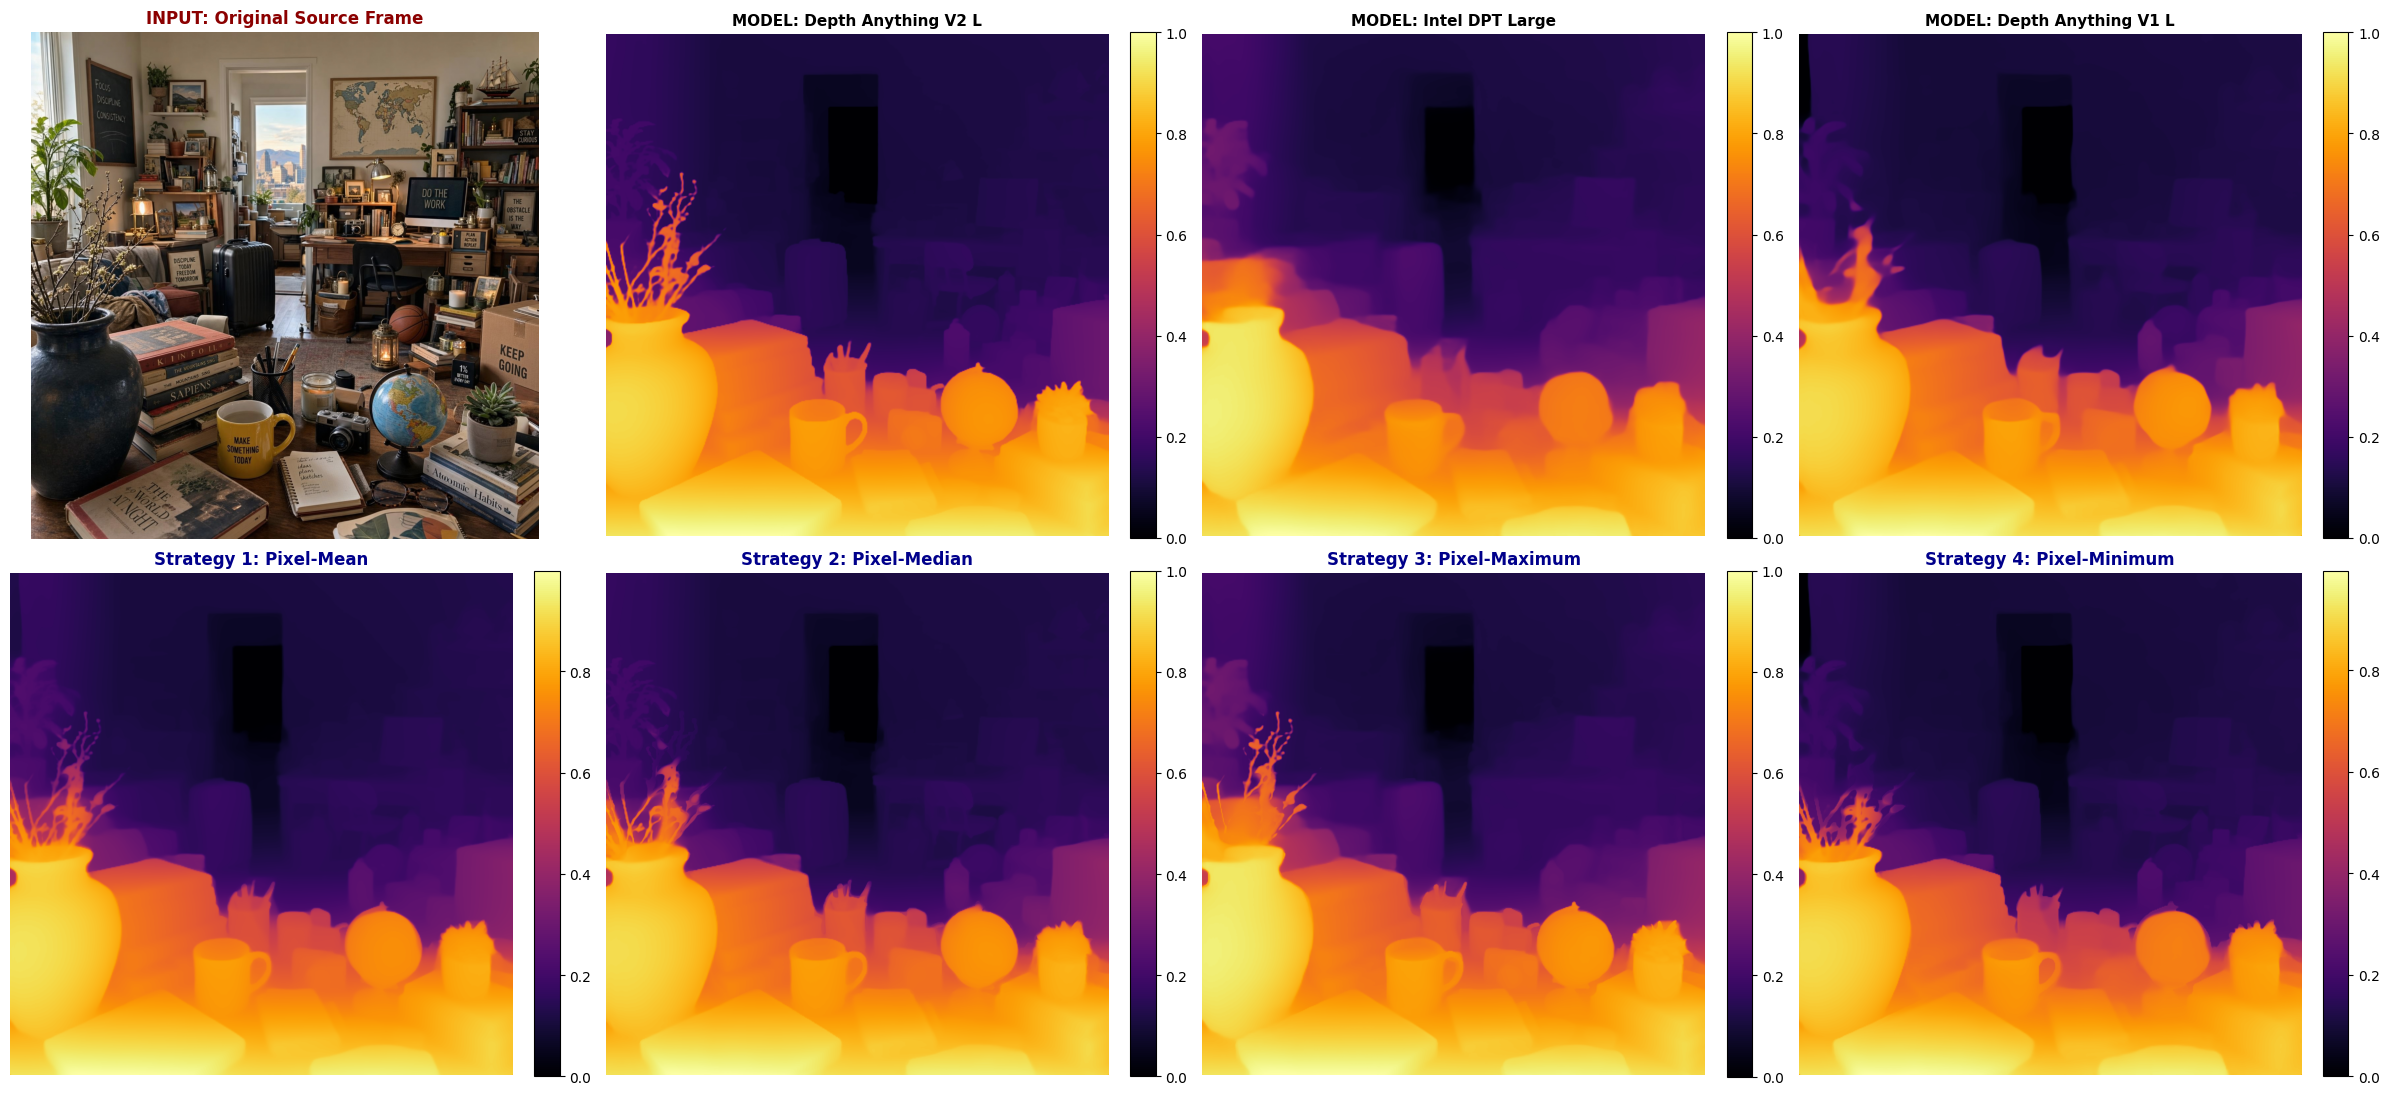


Execution loop finalized. Synced 2x4 collage dashboard saved as: 'comprehensive_ensemble_2x4_analysis.png'


In [1]:
# Comprehensive 4-model depth estimation inference and synchronized 2x4 multi-strategy fusion pipeline
import os
import cv2
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

# Target runtime environment hardware setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_PATH = "depth.jpg"
OUTPUT_COMPREHENSIVE_PATH = "comprehensive_ensemble_2x4_analysis.png"

# Verify image existence before loading components
if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(f"Missing baseline asset: Please upload '{IMAGE_PATH}' to Colab storage.")

# Load raw source image and extract physical dimensions
raw_image = Image.open(IMAGE_PATH).convert("RGB")
original_width, original_height = raw_image.size
print(f"Loaded source frame resolution: {original_width}x{original_height}")

# Defined core 4-model registry within the optimized 200M-500M parameter window (GLPN excluded)
model_registry = {
    "Depth Anything V2 L": "depth-anything/Depth-Anything-V2-Large-hf",
    "Intel DPT Large": "intel/dpt-large",
    "Depth Anything V1 L": "LiheYoung/depth-anything-large-hf",
    "Intel DPT DINOv2 L": "Intel/dpt-dinov2-large"
}

def extract_normalized_depth(model_repo_path: str, img: Image.Image) -> np.ndarray:
    """Execute evaluation forward pass and return a continuous 0-1 normalized depth map."""
    processor = AutoImageProcessor.from_pretrained(model_repo_path)
    model = AutoModelForDepthEstimation.from_pretrained(model_repo_path)
    model.to(DEVICE).eval()

    if DEVICE.type == "cuda":
        model = model.half()

    inputs = processor(images=img, return_tensors="pt").to(DEVICE)
    if DEVICE.type == "cuda":
        inputs = {k: v.half() if torch.is_floating_point(v) else v for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        predicted_depth = outputs.predicted_depth if hasattr(outputs, "predicted_depth") else outputs.depth

    interpolated_depth = torch.nn.functional.interpolate(
        predicted_depth.unsqueeze(1),
        size=(original_height, original_width),
        mode="bilinear",
        align_corners=False,
    ).squeeze()

    depth_map = interpolated_depth.cpu().numpy()

    # Mathematical Scale Alignment using Min-Max scaling boundary
    d_min, d_max = depth_map.min(), depth_map.max()
    normalized = (depth_map - d_min) / (d_max - d_min + 1e-8)
    return normalized

# Gather predictions across all active model pipelines
individual_predictions = {}
aligned_maps_list = []

for model_name, repo_path in model_registry.items():
    print(f"Executing inference and alignment for architecture: {model_name}...")
    try:
        norm_map = extract_normalized_depth(repo_path, raw_image)
        individual_predictions[model_name] = norm_map
        aligned_maps_list.append(norm_map)
    except Exception as e:
        print(f"Skipping architecture {model_name} due to execution fault: {str(e)}")

# Stack individual model arrays into a unified 3D matrix block [4, Height, Width]
ensemble_stack = np.stack(aligned_maps_list, axis=0)

# --- Execute Strategic Ensemble Fusion Logic ---
mean_fusion = np.mean(ensemble_stack, axis=0)
median_fusion = np.median(ensemble_stack, axis=0)
max_fusion = np.max(ensemble_stack, axis=0)
min_fusion = np.min(ensemble_stack, axis=0)

# Dictionary grouping strategies for automated grid plotting mapping
fusion_strategies = {
    "Strategy 1: Pixel-Mean": mean_fusion,
    "Strategy 2: Pixel-Median": median_fusion,
    "Strategy 3: Pixel-Maximum": max_fusion,
    "Strategy 4: Pixel-Minimum": min_fusion
}

# --- Structural Multi-Row Grid Plot Layout Generation (2 Rows x 4 Columns = 8 cells) ---
fig, axes = plt.subplots(2, 4, figsize=(24, 11))
axes_flat = axes.ravel() # Safely flatten the 2D multi-dimensional axes array

# Title banner styling configuration parameters
title_font = {"fontsize": 11, "weight": "bold"}

# --- ROW 1: Input Frame + Three Individual Models ---
# Cell 0: Reference baseline input image
axes_flat[0].imshow(raw_image)
axes_flat[0].set_title("INPUT: Original Source Frame", fontdict={"fontsize": 12, "weight": "bold", "color": "darkred"})
axes_flat[0].axis("off")

# Cells 1 to 4: Plot individual model prediction responses dynamically on row 1
for idx, (model_name, prediction_matrix) in enumerate(individual_predictions.items(), start=1):
    ax = axes_flat[idx]
    im = ax.imshow(prediction_matrix, cmap="inferno")
    ax.set_title(f"MODEL: {model_name}", fontdict=title_font)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# --- ROW 2: Four Fusion Strategies ---
# Cells 4 to 7: Plot strategic ensemble fusion outputs across the entire second row sequence
for idx, (strategy_name, fusion_matrix) in enumerate(fusion_strategies.items(), start=4):
    ax = axes_flat[idx]
    im = ax.imshow(fusion_matrix, cmap="inferno")
    ax.set_title(strategy_name, fontdict={"fontsize": 12, "weight": "bold", "color": "darkblue"})
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Global layout optimization adjustments
plt.tight_layout()
plt.savefig(OUTPUT_COMPREHENSIVE_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nExecution loop finalized. Synced 2x4 collage dashboard saved as: '{OUTPUT_COMPREHENSIVE_PATH}'")


Streaming dataset partition for structural inspection...


Resolving data files:   0%|          | 0/157 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/157 [00:00<?, ?it/s]


============================== DATASET SCHEMA INSPECTION ==============================
Available features/keys in sample dictionary: ['image', 'depth_map']

Dynamically mapped image key: 'image'
Dynamically mapped ground truth depth key: 'depth_map'

=============================== DESCRIPTIVE STATISTICS ===============================
RGB Input Shape:      (480, 640, 3) (Height x Width x Channels)
Depth Map Shape:      (480, 640) (Height x Width)
RGB Pixel Range:      Min = 0, Max = 255
Raw Depth Range:      Min = 1.7986, Max = 3.6156
Depth Mean / Std:     Mean = 2.8796, Std = 0.4212


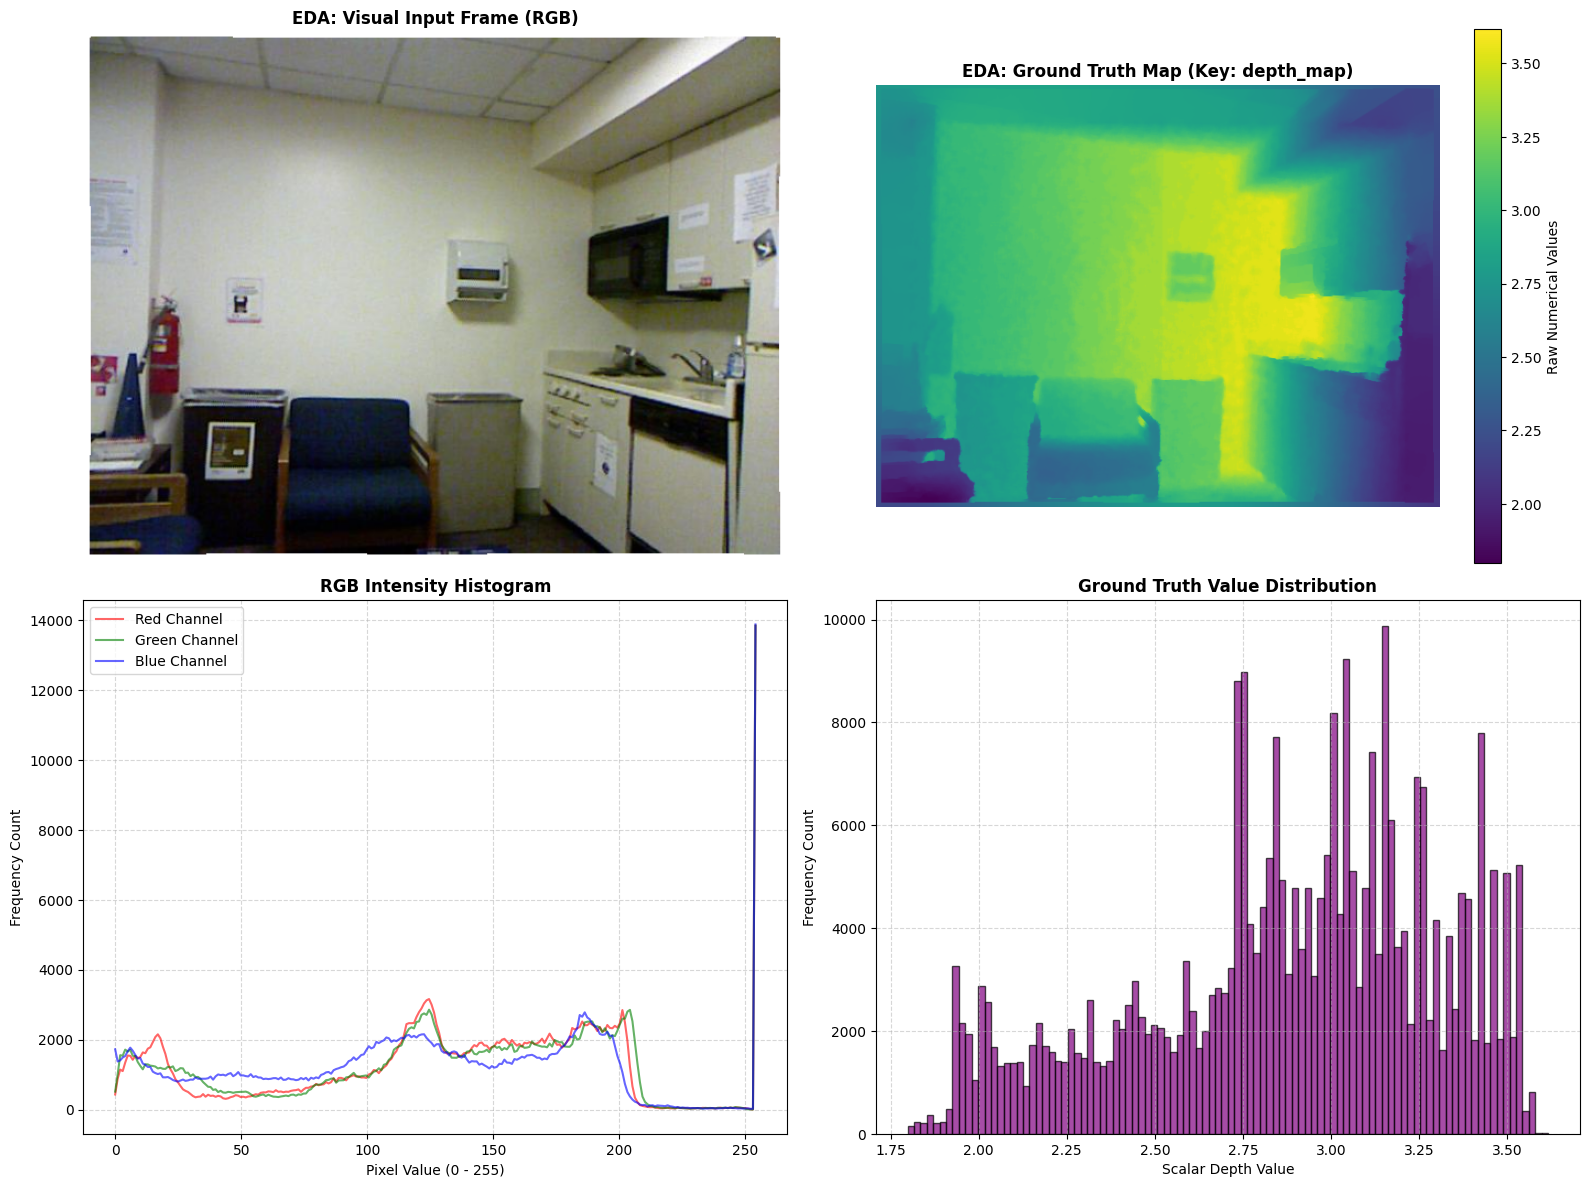


EDA phase finalized successfully. Insights dashboard saved as: 'dataset_eda_insight.png'


In [7]:
# Exploratory Data Analysis (EDA) pipeline for NYU Depth V2 dataset structure and pixel distribution
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

# 1. Load a streaming instance of the dataset partition
print("Streaming dataset partition for structural inspection...")
dataset = load_dataset("vikhyatk/nyu_depth_v2", split="validation", streaming=True)

# Extract the very first sample container
iterator = iter(dataset)
sample_sample = next(iterator)

# 2. Inspect dictionary schema keys to detect exact column names
print("\n" + "="*30 + " DATASET SCHEMA INSPECTION " + "="*30)
print(f"Available features/keys in sample dictionary: {list(sample_sample.keys())}")
print("="*87 + "\n")

# Dynamically map keys based on detected schema to prevent KeyError crashes
image_key = "image"
depth_key = "depth" if "depth" in sample_sample else [k for k in sample_sample.keys() if "depth" in k.lower()][0]

print(f"Dynamically mapped image key: '{image_key}'")
print(f"Dynamically mapped ground truth depth key: '{depth_key}'\n")

# Extract arrays and metadata descriptions
raw_image = sample_sample[image_key].convert("RGB")
gt_depth_raw = sample_sample[depth_key]

# Convert structural data inputs into numerical arrays
img_array = np.array(raw_image)
depth_array = np.array(gt_depth_raw, dtype=np.float32)

# Compute baseline descriptive metrics
print("="*31 + " DESCRIPTIVE STATISTICS " + "="*31)
print(f"RGB Input Shape:      {img_array.shape} (Height x Width x Channels)")
print(f"Depth Map Shape:      {depth_array.shape} (Height x Width)")
print(f"RGB Pixel Range:      Min = {img_array.min()}, Max = {img_array.max()}")
print(f"Raw Depth Range:      Min = {depth_array.min():.4f}, Max = {depth_array.max():.4f}")
print(f"Depth Mean / Std:     Mean = {depth_array.mean():.4f}, Std = {depth_array.summary() if hasattr(depth_array, 'summary') else depth_array.std():.4f}")
print("="*87)

# 3. Generate visual analysis dashboard (Source, Target, and Distribution Histograms)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: Source Image Frame
axes[0, 0].imshow(raw_image)
axes[0, 0].set_title("EDA: Visual Input Frame (RGB)", fontsize=12, weight="bold")
axes[0, 0].axis("off")

# Subplot 2: Ground Truth Depth Mask
im_depth = axes[0, 1].imshow(depth_array, cmap="viridis")
axes[0, 1].set_title(f"EDA: Ground Truth Map (Key: {depth_key})", fontsize=12, weight="bold")
fig.colorbar(im_depth, ax=axes[0, 1], label="Raw Numerical Values")
axes[0, 1].axis("off")

# Subplot 3: RGB Color Channels Distribution Histogram
colors = ("red", "green", "blue")
for i, color in enumerate(colors):
    hist, bin_edges = np.histogram(img_array[:, :, i], bins=256, range=(0, 255))
    axes[1, 0].plot(bin_edges[0:-1], hist, color=color, alpha=0.6, label=f"{color.capitalize()} Channel")
axes[1, 0].set_title("RGB Intensity Histogram", fontsize=12, weight="bold")
axes[1, 0].set_xlabel("Pixel Value (0 - 255)")
axes[1, 0].set_ylabel("Frequency Count")
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle="--", alpha=0.5)

# Subplot 4: Depth Value Density Distribution Histogram
axes[1, 1].hist(depth_array.ravel(), bins=100, color="purple", alpha=0.7, edgecolor="black")
axes[1, 1].set_title("Ground Truth Value Distribution", fontsize=12, weight="bold")
axes[1, 1].set_xlabel("Scalar Depth Value")
axes[1, 1].set_ylabel("Frequency Count")
axes[1, 1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("dataset_eda_insight.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nEDA phase finalized successfully. Insights dashboard saved as: 'dataset_eda_insight.png'")


In [10]:
# Fixed Cross-Domain EDA pipeline for Indoor, Outdoor, and Aerial Depth Datasets
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

def perform_domain_eda(dataset_path: str, domain_label: str, split_name: str = "validation"):
    """Stream a single sample from an open repository, auto-detect features, and extract stats."""
    print(f"\n" + "="*20 + f" LOADING DOMAIN: {domain_label.upper()} " + "="*20)

    # Cascade fallback sequence for split discovery
    dataset = None
    for split in [split_name, "train", "test"]:
        try:
            dataset = load_dataset(dataset_path, split=split, streaming=True)
            print(f"Successfully connected to dataset partition split: '{split}'")
            break
        except Exception:
            continue

    if dataset is None:
        raise ValueError(f"Unable to resolve any active split partitions for repository: {dataset_path}")

    sample = next(iter(dataset))
    keys = list(sample.keys())
    print(f"Detected internal schema keys: {keys}")

    # Smart dynamic extraction matching for image and depth keys
    image_key = "image" if "image" in keys else [k for k in keys if "img" in k.lower()][0]

    # Priority matching sequence based on known schemas
    depth_candidates = ["depth_map", "depth", "label", "depth_linear"]
    depth_key = None
    for candidate in depth_candidates:
        if candidate in keys:
            depth_key = candidate
            break

    if depth_key is None:
        depth_key = [k for k in keys if "depth" in k.lower() or "label" in k.lower()][0]

    print(f"Using keys -> Image: '{image_key}', Depth Map Target: '{depth_key}'")

    # Extract data components into numerical matrices
    raw_image = sample[image_key].convert("RGB")
    raw_depth = sample[depth_key]

    img_array = np.array(raw_image)
    depth_array = np.array(raw_depth, dtype=np.float32)

    # Filter out masking tokens or empty LiDAR returns (values <= 0)
    valid_depth = depth_array[depth_array > 0]
    if len(valid_depth) == 0:
        valid_depth = depth_array

    print(f"Resolution layout:  {img_array.shape[0]}x{img_array.shape[1]}")
    print(f"Depth Scalar Scale: Min = {valid_depth.min():.4f}, Max = {valid_depth.max():.4f}")
    print(f"Depth Dispersion:   Mean = {valid_depth.mean():.4f}, Std = {valid_depth.std():.4f}")
    print("="*65)

    return raw_image, depth_array, valid_depth

# Execute robust domain retrieval across stable target repositories
img_in, depth_in, valid_in = perform_domain_eda("vikhyatk/nyu_depth_v2", "Indoor (Rooms)")
img_out, depth_out, valid_out = perform_domain_eda("sayakpaul/kitti-depth-sample", "Outdoor (Automotive)")
img_air, depth_air, valid_air = perform_domain_eda("sayakpaul/diode-sample", "Aerial / Structural Openings")

# --- Comprehensive Cross-Domain Visual Dashboard Generation ---
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# --- Row 1: Indoor Domain Visualization ---
axes[0, 0].imshow(img_in)
axes[0, 0].set_title("Indoor: RGB Source Frame", fontsize=11, weight="bold")
axes[0, 0].axis("off")

im1 = axes[0, 1].imshow(depth_in, cmap="plasma")
axes[0, 1].set_title("Indoor: Ground Truth Map", fontsize=11, weight="bold")
fig.colorbar(im1, ax=axes[0, 1], label="Distance Metrics")
axes[0, 1].axis("off")

axes[0, 2].hist(valid_in.ravel(), bins=50, color="teal", alpha=0.7, edgecolor="black")
axes[0, 2].set_title("Indoor: Value Density Distribution", fontsize=11, weight="bold")
axes[0, 2].grid(True, linestyle="--", alpha=0.5)

# --- Row 2: Outdoor Domain Visualization ---
axes[1, 0].imshow(img_out)
axes[1, 0].set_title("Outdoor: RGB Source Frame", fontsize=11, weight="bold")
axes[1, 0].axis("off")

im2 = axes[1, 1].imshow(depth_out, cmap="magma")
axes[1, 1].set_title("Outdoor: Ground Truth Map (LiDAR)", fontsize=11, weight="bold")
fig.colorbar(im2, ax=axes[1, 1], label="Distance Metrics")
axes[1, 1].axis("off")

axes[1, 2].hist(valid_out.ravel(), bins=50, color="orange", alpha=0.7, edgecolor="black")
axes[1, 2].set_title("Outdoor: Value Density Distribution", fontsize=11, weight="bold")
axes[1, 2].grid(True, linestyle="--", alpha=0.5)

# --- Row 3: Aerial Domain Visualization ---
axes[2, 0].imshow(img_air)
axes[2, 0].set_title("Aerial: RGB Source Frame", fontsize=11, weight="bold")
axes[2, 0].axis("off")

im3 = axes[2, 1].imshow(depth_air, cmap="viridis")
axes[2, 1].set_title("Aerial: Ground Truth Map", fontsize=11, weight="bold")
fig.colorbar(im3, ax=axes[2, 1], label="Distance Metrics")
axes[2, 1].axis("off")

axes[2, 2].hist(valid_air.ravel(), bins=50, color="purple", alpha=0.7, edgecolor="black")
axes[2, 2].set_title("Aerial: Value Density Distribution", fontsize=11, weight="bold")
axes[2, 2].grid(True, linestyle="--", alpha=0.5)

# Optimize presentation spaces and save matrix plots
plt.tight_layout()
plt.savefig("cross_domain_eda_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nCross-domain EDA process completed successfully. Final matrix saved as: 'cross_domain_eda_dashboard.png'")



==================== LOADING DOMAIN: INDOOR (ROOMS) ====================


Resolving data files:   0%|          | 0/157 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/157 [00:00<?, ?it/s]

Successfully connected to dataset partition split: 'validation'
Detected internal schema keys: ['image', 'depth_map']
Using keys -> Image: 'image', Depth Map Target: 'depth_map'
Resolution layout:  480x640
Depth Scalar Scale: Min = 1.7986, Max = 3.6156
Depth Dispersion:   Mean = 2.8796, Std = 0.4212

==================== LOADING DOMAIN: OUTDOOR (AUTOMOTIVE) ====================


ValueError: Unable to resolve any active split partitions for repository: sayakpaul/kitti-depth-sample